# 🧠 ResearchMind AI: Smart Research Paper Assistant
### Retrieval-Augmented Generation (RAG) + Deep Learning + AI Agents

---

## 📌 What Problem Does This Solve?

Researchers spend enormous amounts of time reading, comparing, and summarizing papers.
**ResearchMind AI** automates the heavy lifting of literature work:

- Upload one or more research papers (PDF)
- Automatically extract title, authors, abstract, body text, and references
- Ask natural-language questions and get grounded answers (RAG)
- Summarize papers at multiple levels of depth
- Compare multiple papers side-by-side
- Auto-generate literature reviews and detect research gaps
- Generate citations (APA / MLA / IEEE / Chicago)
- Classify papers by ML sub-field using a fine-tuned transformer
- Recommend related papers using embedding similarity
- Visualize a knowledge graph of concepts, authors, and models
- Coordinate all of this through a small multi-agent system
- Interact with everything through an in-notebook UI (ipywidgets)

## 🏗️ Architecture Overview

```
                     ┌─────────────────────┐
                     │   PDF Upload (Colab) │
                     └──────────┬───────────┘
                                ▼
                     ┌─────────────────────┐
                     │  PyMuPDF Extraction │  → Title / Authors / Abstract / Body / Refs
                     └──────────┬───────────┘
                                ▼
                     ┌─────────────────────┐
                     │   Recursive Chunker │  → Overlapping text chunks + metadata
                     └──────────┬───────────┘
                                ▼
                     ┌─────────────────────┐
                     │ Sentence-Transformer│  → Dense vector embeddings
                     └──────────┬───────────┘
                                ▼
                     ┌─────────────────────┐
                     │     FAISS Index     │  → Similarity search / retrieval
                     └──────────┬───────────┘
                                ▼
        ┌───────────────────────┴────────────────────────┐
        ▼                                                 ▼
┌───────────────┐                                 ┌────────────────┐
│  Groq LLM RAG │  → Q&A, Summaries, Lit Reviews   │  AI Agent Layer│
└───────────────┘                                 └────────────────┘
        │                                                 │
        └───────────────────────┬────────────────────────┘
                                 ▼
                     ┌─────────────────────┐
                     │  Knowledge Graph /  │
                     │  Widgets UI / Plots │
                     └─────────────────────┘
```

## 🛠️ Technologies Used

| Layer | Tool |
|---|---|
| LLM Inference | Groq API (`llama-3.3-70b-versatile`, `deepseek-r1-distill-llama-70b`, `gemma2-9b-it`) |
| Orchestration | LangChain |
| Embeddings | Sentence-Transformers (`all-MiniLM-L6-v2`) |
| Vector Store | FAISS |
| PDF Parsing | PyMuPDF (fitz) |
| Classification | DistilBERT (fine-tuned) |
| Graph | NetworkX + Matplotlib |
| UI | ipywidgets |
| Data | Pandas, NumPy, Scikit-learn |

> ⚠️ **Note:** This notebook is designed to run top-to-bottom in **Google Colab**. You will need a free Groq API key from https://console.groq.com/keys.


## 1️⃣ Install Dependencies

Run this cell first. It installs everything needed for the rest of the notebook.


In [3]:
!pip install -q langchain langchain-community langchain-groq langchain-text-splitters\
    sentence-transformers faiss-cpu transformers torch accelerate \
    pymupdf networkx matplotlib scikit-learn pandas numpy ipywidgets groq

print("✅ All dependencies installed successfully.")

✅ All dependencies installed successfully.


## 2️⃣ Import Libraries

All imports are grouped by purpose for readability.


In [5]:
# ----- Standard library -----
import os
import re
import json
import time
import textwrap
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

warnings.filterwarnings("ignore")

# ----- Data / numerics -----
import numpy as np
import pandas as pd

# ----- PDF processing -----
import fitz  # PyMuPDF

# ----- Embeddings & vector search -----
from sentence_transformers import SentenceTransformer
import faiss

# ----- Deep learning -----
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

# ----- LangChain / Groq -----
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

# ----- Graph & visualization -----
import networkx as nx
import matplotlib.pyplot as plt

# ----- Metrics -----
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# ----- Colab-specific -----
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ----- UI -----
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

print("✅ Libraries imported. Running in Colab:", IN_COLAB)


✅ Libraries imported. Running in Colab: True


## 3️⃣ Groq API Configuration

Get a **free** API key at https://console.groq.com/keys and paste it below.
We use fast, free-tier-friendly Groq models.


In [24]:
GROQ_API_KEY = "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"  # <-- paste your key here

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# Available Groq models used across this notebook
GROQ_MODELS = {
    "fast": "llama-3.1-8b-instant",
    "reasoning": "llama-3.3-70b-versatile",
    "lightweight": "llama-3.1-8b-instant",
}

def get_llm(model_key: str = "fast", temperature: float = 0.3):
    """Factory function that returns a configured ChatGroq client."""
    return ChatGroq(
        model=GROQ_MODELS[model_key],
        temperature=temperature,
        api_key=GROQ_API_KEY,
    )

# Quick sanity check (will raise a clear error if the key is missing/invalid)
try:
    llm = get_llm("fast")
    test = llm.invoke([HumanMessage(content="Reply with the single word: OK")])
    print("✅ Groq connection working. Response:", test.content)
except Exception as e:
    print("⚠️ Could not verify Groq connection. Check your API key.")
    print("Error:", e)

✅ Groq connection working. Response: OK


## 4️⃣ Upload Research Papers

Upload one or more PDF files. These will be stored in `uploaded_pdf_paths`.


In [7]:
uploaded_pdf_paths = []

if IN_COLAB:
    uploaded = files.upload()
    for fname in uploaded.keys():
        uploaded_pdf_paths.append(fname)
    print(f"✅ Uploaded {len(uploaded_pdf_paths)} file(s):", uploaded_pdf_paths)
else:
    print("Not running in Colab — set `uploaded_pdf_paths` manually to a list of local PDF paths.")
    # Example: uploaded_pdf_paths = ["paper1.pdf", "paper2.pdf"]


Saving IEEE_PAPER.pdf to IEEE_PAPER.pdf
✅ Uploaded 1 file(s): ['IEEE_PAPER.pdf']


## 5️⃣ PDF Processing Pipeline

We extract structured fields — **title, authors, abstract, main text, references** —
from each PDF using PyMuPDF and lightweight heuristics/regex.


In [8]:
@dataclass
class PaperDocument:
    filename: str
    title: str = ""
    authors: str = ""
    abstract: str = ""
    body_text: str = ""
    references: str = ""
    full_text: str = ""
    num_pages: int = 0


def extract_text_by_page(pdf_path: str) -> List[str]:
    """Extract raw text from each page of a PDF."""
    pages = []
    try:
        with fitz.open(pdf_path) as doc:
            for page in doc:
                pages.append(page.get_text("text"))
    except Exception as e:
        print(f"⚠️ Error reading {pdf_path}: {e}")
    return pages


def guess_title(first_page: str) -> str:
    """Heuristic: the title is usually the first non-empty, reasonably long line."""
    lines = [l.strip() for l in first_page.split("\n") if l.strip()]
    for line in lines[:8]:
        if 15 < len(line) < 200 and not line.lower().startswith(("abstract", "arxiv")):
            return line
    return lines[0] if lines else "Unknown Title"


def guess_authors(first_page: str, title: str) -> str:
    """Heuristic: authors usually appear on the line(s) right after the title."""
    lines = [l.strip() for l in first_page.split("\n") if l.strip()]
    if title in lines:
        idx = lines.index(title)
        candidates = lines[idx + 1: idx + 3]
        return "; ".join(candidates) if candidates else "Unknown Authors"
    return "Unknown Authors"


def extract_section(full_text: str, start_keywords: List[str], end_keywords: List[str]) -> str:
    """Generic regex-based section extractor between two sets of keywords."""
    text_lower = full_text.lower()
    start_idx = -1
    for kw in start_keywords:
        idx = text_lower.find(kw)
        if idx != -1:
            start_idx = idx
            break
    if start_idx == -1:
        return ""

    end_idx = len(full_text)
    for kw in end_keywords:
        idx = text_lower.find(kw, start_idx + 10)
        if idx != -1:
            end_idx = min(end_idx, idx)

    return full_text[start_idx:end_idx].strip()


def clean_text(text: str) -> str:
    """Fix common OCR/PDF extraction noise: broken hyphenation, extra whitespace, etc."""
    text = re.sub(r"-\n", "", text)          # de-hyphenate line-broken words
    text = re.sub(r"\n+", " ", text)          # merge broken lines
    text = re.sub(r"\s{2,}", " ", text)        # collapse multiple spaces
    return text.strip()


def process_pdf(pdf_path: str) -> PaperDocument:
    pages = extract_text_by_page(pdf_path)
    full_text = "\n".join(pages)
    first_page = pages[0] if pages else ""

    title = guess_title(first_page)
    authors = guess_authors(first_page, title)
    abstract = extract_section(full_text, ["abstract"], ["1 introduction", "introduction", "keywords"])
    references = extract_section(full_text, ["references", "bibliography"], ["appendix"])

    body_start = full_text.lower().find("introduction")
    body_text = full_text[body_start:] if body_start != -1 else full_text

    return PaperDocument(
        filename=pdf_path,
        title=clean_text(title),
        authors=clean_text(authors),
        abstract=clean_text(abstract)[:3000],
        body_text=clean_text(body_text),
        references=clean_text(references)[:3000],
        full_text=clean_text(full_text),
        num_pages=len(pages),
    )


papers: List[PaperDocument] = []
for path in uploaded_pdf_paths:
    doc = process_pdf(path)
    papers.append(doc)
    print(f"📄 {doc.filename} — {doc.num_pages} pages")
    print(f"   Title:   {doc.title[:100]}")
    print(f"   Authors: {doc.authors[:100]}")
    print(f"   Abstract: {doc.abstract[:200]}...\n")


📄 IEEE_PAPER.pdf — 6 pages
   Title:   AgriAdvisor: A Conceptual Framework for
   Authors: Dual-Platform (PWA + Mobile), LLM-RAG; Augmented Intelligent Crop Advisory System Using
   Abstract: Abstract—Agriculture employs nearly 42.3% of India’s workforce. It contributes close to 18% of national GDP. Yet 89.4% of Indian farm households are small or marginal landholders, and the infrastructu...



## 6️⃣ Text Chunking

We split each paper's full text into overlapping chunks using a recursive splitter,
preserving metadata (source filename, chunk index) for later retrieval.


✅ Generated 46 chunks from 1 paper(s).


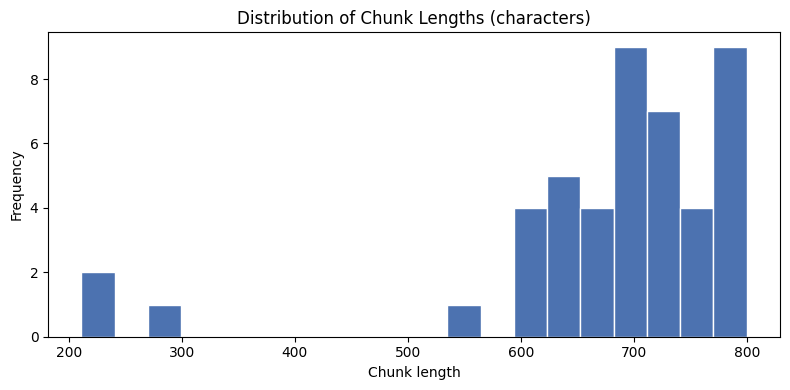

Chunk length stats:
count     46.000000
mean     674.500000
std      131.447793
min      211.000000
25%      643.000000
50%      698.500000
75%      747.000000
max      800.000000
dtype: float64


In [9]:
@dataclass
class Chunk:
    text: str
    source: str
    chunk_id: int


splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_chunks: List[Chunk] = []
for doc in papers:
    pieces = splitter.split_text(doc.full_text)
    for i, piece in enumerate(pieces):
        all_chunks.append(Chunk(text=piece, source=doc.filename, chunk_id=i))

print(f"✅ Generated {len(all_chunks)} chunks from {len(papers)} paper(s).")

# ----- Visualize chunk statistics -----
chunk_lengths = [len(c.text) for c in all_chunks]
if chunk_lengths:
    plt.figure(figsize=(8, 4))
    plt.hist(chunk_lengths, bins=20, color="#4C72B0", edgecolor="white")
    plt.title("Distribution of Chunk Lengths (characters)")
    plt.xlabel("Chunk length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print("Chunk length stats:")
    print(pd.Series(chunk_lengths).describe())


## 7️⃣ Embedding Generation

We use `sentence-transformers/all-MiniLM-L6-v2` — a fast, high-quality, free embedding model.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Embeddings shape: (46, 384)


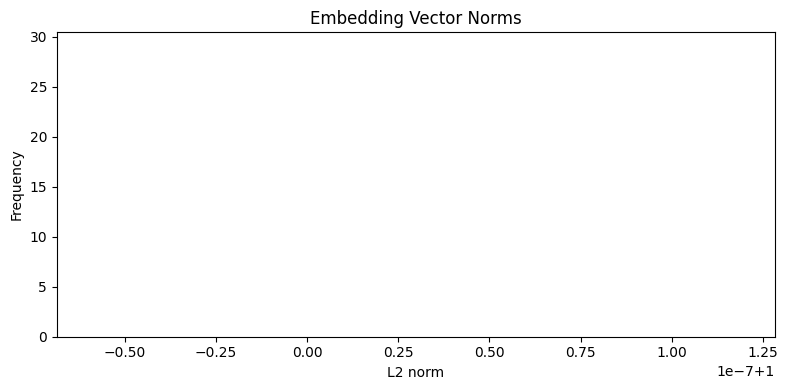

In [10]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

chunk_texts = [c.text for c in all_chunks]
chunk_embeddings = embedding_model.encode(
    chunk_texts, show_progress_bar=True, convert_to_numpy=True
) if chunk_texts else np.zeros((0, 384))

print(f"✅ Embeddings shape: {chunk_embeddings.shape}")

# ----- Visualize embedding norm distribution -----
if len(chunk_embeddings):
    norms = np.linalg.norm(chunk_embeddings, axis=1)
    plt.figure(figsize=(8, 4))
    plt.hist(norms, bins=20, color="#DD8452", edgecolor="white")
    plt.title("Embedding Vector Norms")
    plt.xlabel("L2 norm")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 8️⃣ Vector Database (FAISS)

We build a FAISS index for fast similarity search, and demonstrate persistence
(save/load) as well as a simple retrieval example.


In [11]:
dimension = chunk_embeddings.shape[1] if len(chunk_embeddings) else 384
faiss_index = faiss.IndexFlatL2(dimension)

if len(chunk_embeddings):
    faiss_index.add(chunk_embeddings.astype("float32"))

print(f"✅ FAISS index built with {faiss_index.ntotal} vectors.")

FAISS_INDEX_PATH = "researchmind_faiss.index"
faiss.write_index(faiss_index, FAISS_INDEX_PATH)
print(f"💾 Index persisted to '{FAISS_INDEX_PATH}'")


def similarity_search(query: str, k: int = 5) -> List[Tuple[Chunk, float]]:
    """Return top-k most similar chunks to the query, with distances."""
    if faiss_index.ntotal == 0:
        return []
    q_emb = embedding_model.encode([query], convert_to_numpy=True).astype("float32")
    distances, indices = faiss_index.search(q_emb, min(k, faiss_index.ntotal))
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx != -1:
            results.append((all_chunks[idx], float(dist)))
    return results


# Example
example_results = similarity_search("What is the main contribution of this paper?", k=3)
for chunk, dist in example_results:
    print(f"[{chunk.source} | chunk {chunk.chunk_id} | dist={dist:.3f}]")
    print(textwrap.shorten(chunk.text, width=150), "\n")


✅ FAISS index built with 46 vectors.
💾 Index persisted to 'researchmind_faiss.index'
[IEEE_PAPER.pdf | chunk 12 | dist=1.441]
. B. Nine Studies, One Recurring Blind Spot Table I summarizes the nine primary studies examined in this review. They span IEEE Access, the [...] 

[IEEE_PAPER.pdf | chunk 22 | dist=1.495]
. 4) Disconnection between explainability and farmerfacing output. SHAP-based explainability, where present [3], [5], is not connected to any [...] 

[IEEE_PAPER.pdf | chunk 5 | dist=1.541]
. At the same time, the research community has made genuine progress on crop yield prediction. Ensemble methods such as Random Forest and [...] 



## 9️⃣ Build the RAG Pipeline

`Document → Chunking → Embedding → FAISS → Retriever → Groq LLM → Response`


In [12]:
RAG_SYSTEM_PROMPT = (
    "You are ResearchMind AI, an expert research assistant. "
    "Answer the user's question using ONLY the provided context from research papers. "
    "If the answer isn't in the context, say so honestly. Be precise and cite paper filenames "
    "when relevant."
)


def build_context(chunks_with_scores: List[Tuple[Chunk, float]]) -> str:
    parts = []
    for chunk, _ in chunks_with_scores:
        parts.append(f"[Source: {chunk.source}]\n{chunk.text}")
    return "\n\n---\n\n".join(parts)


def ask_question(question: str, k: int = 5, model_key: str = "fast") -> str:
    """Full RAG call: retrieve relevant chunks, then ask Groq LLM grounded on them."""
    retrieved = similarity_search(question, k=k)
    context = build_context(retrieved)

    llm = get_llm(model_key)
    messages = [
        SystemMessage(content=RAG_SYSTEM_PROMPT),
        HumanMessage(content=f"Context:\n{context}\n\nQuestion: {question}"),
    ]
    response = llm.invoke(messages)
    return response.content


# ----- Example questions -----
example_questions = [
    "What is the paper about?",
    "Explain the methodology.",
    "What are the limitations?",
    "Compare this paper with others.",
]

for q in example_questions:
    print(f"❓ {q}")
    try:
        print(ask_question(q), "\n" + "-" * 80)
    except Exception as e:
        print(f"⚠️ Could not get an answer (check Groq API key): {e}\n")


❓ What is the paper about?
The paper is about the "delivery gap" in crop yield prediction research, where the focus has been on improving prediction accuracy using machine learning and deep learning techniques, but little attention has been paid to how these predictions are delivered to farmers in a usable form. The paper identifies this gap through a review of nine peer-reviewed studies and proposes a solution, AgriAdvisor, to address this issue (IEEE_PAPER.pdf). 
--------------------------------------------------------------------------------
❓ Explain the methodology.
The methodology is not explicitly explained in the provided context. The context appears to focus on the analysis of existing studies and the identification of gaps in the current research, particularly in the area of explainable AI and delivery mechanisms for agricultural advisory systems. It discusses the limitations of current systems and the need for a more effective delivery mechanism, but it does not provide a cl

## 🔟 Research Paper Summarization

Generate summaries at multiple levels: short, detailed, beginner-friendly, and bullet-point.


In [13]:
SUMMARY_PROMPTS = {
    "short": "Summarize the following paper in 2-3 sentences:\n\n{text}",
    "detailed": "Write a detailed, multi-paragraph summary of the following paper, covering "
                "motivation, method, results, and conclusions:\n\n{text}",
    "beginner": "Explain the following paper in simple terms a beginner with no ML background "
                "could understand:\n\n{text}",
    "bullets": "Summarize the following paper as a concise bullet-point list "
               "(motivation, method, results, limitations):\n\n{text}",
}


def summarize_paper(doc: PaperDocument, style: str = "short", model_key: str = "fast") -> str:
    prompt = SUMMARY_PROMPTS[style].format(text=doc.abstract or doc.full_text[:4000])
    llm = get_llm(model_key)
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content


if papers:
    for style in SUMMARY_PROMPTS:
        print(f"=== {style.upper()} SUMMARY: {papers[0].filename} ===")
        try:
            print(summarize_paper(papers[0], style), "\n")
        except Exception as e:
            print(f"⚠️ Skipped ({e})\n")


=== SHORT SUMMARY: IEEE_PAPER.pdf ===
Here is a summary of the paper in 2-3 sentences:

Despite significant advancements in precision agriculture and crop yield prediction using machine learning, there is a significant "delivery gap" in how these predictions are communicated to smallholder farmers in India, who make up 89.4% of farm households. This paper proposes AgriAdvisor, a framework that uses Large Language Models and open government datasets to provide advisory services to farmers, without relying on IoT hardware or stable connectivity. The framework aims to address the delivery gap and support sustainable agriculture practices among smallholder farmers in India. 

=== DETAILED SUMMARY: IEEE_PAPER.pdf ===
The paper addresses a significant issue in Indian agriculture, where despite employing nearly 42.3% of the workforce and contributing 18% to the national GDP, the majority of farm households (89.4%) are small or marginal landholders who lack access to the infrastructure require

## 1️⃣1️⃣ Multi-Paper Comparison Engine

Build a structured comparison table (Authors, Methodology, Dataset, Model, Results,
Advantages, Limitations) across all uploaded papers.


In [14]:
COMPARISON_PROMPT = (
    "Analyze the following research paper text and extract these fields as short phrases:\n"
    "Methodology, Dataset, Model, Results, Advantages, Limitations.\n"
    "Respond ONLY as valid JSON with these exact keys (no extra text):\n"
    '{{"methodology": "...", "dataset": "...", "model": "...", "results": "...", '
    '"advantages": "...", "limitations": "..."}}\n\n'
    "Paper text:\n{text}"
)


def extract_comparison_fields(doc: PaperDocument, model_key: str = "fast") -> dict:
    prompt = COMPARISON_PROMPT.format(text=doc.abstract + " " + doc.body_text[:3000])
    llm = get_llm(model_key, temperature=0)
    response = llm.invoke([HumanMessage(content=prompt)])
    raw = response.content.strip()
    raw = re.sub(r"^```json|```$", "", raw, flags=re.MULTILINE).strip()
    try:
        return json.loads(raw)
    except Exception:
        return {k: "" for k in
                ["methodology", "dataset", "model", "results", "advantages", "limitations"]}


comparison_rows = []
for doc in papers:
    try:
        fields = extract_comparison_fields(doc)
    except Exception as e:
        fields = {k: "" for k in
                  ["methodology", "dataset", "model", "results", "advantages", "limitations"]}
        print(f"⚠️ Could not extract fields for {doc.filename}: {e}")
    fields["filename"] = doc.filename
    fields["authors"] = doc.authors
    comparison_rows.append(fields)

comparison_df = pd.DataFrame(comparison_rows)[
    ["filename", "authors", "methodology", "dataset", "model",
     "results", "advantages", "limitations"]
] if comparison_rows else pd.DataFrame()

comparison_df


,filename,authors,methodology,dataset,model,results,advantages,limitations
0,IEEE_PAPER.pdf,"Dual-Platform (PWA + Mobile), LLM-RAG; Augment...",Systematic review and conceptual framework,Indian government open datasets,Large Language Model (LLM) and Retrieval-Augme...,Improved yield prediction accuracy and deliver...,"No IoT hardware required, functional under low...",Dependence on government datasets and limited ...


## 1️⃣2️⃣ Literature Review Generator

Provide a topic; ResearchMind AI drafts a structured literature review grounded in
the uploaded papers' content.


In [25]:
LIT_REVIEW_PROMPT = """You are writing an academic literature review on the topic: "{topic}".

Use the following paper excerpts as source material:
{sources}

Structure your review with these sections:
1. Introduction
2. Previous Work
3. Existing Approaches
4. Research Gaps
5. Future Directions
6. Conclusion
"""


def generate_literature_review(topic: str, model_key: str = "reasoning") -> str:
    sources = "\n\n".join(
        f"[{doc.filename}] {doc.abstract[:800]}" for doc in papers
    ) or "No papers uploaded — write a general review based on known literature."

    prompt = LIT_REVIEW_PROMPT.format(topic=topic, sources=sources)
    llm = get_llm(model_key)
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content


topic_input = "Large Language Models"
try:
    review = generate_literature_review(topic_input)
    display(Markdown(review))
except Exception as e:
    print(f"⚠️ Could not generate literature review: {e}")

## 1. Introduction
The advent of Large Language Models (LLMs) has revolutionized various domains, including agriculture, by leveraging machine learning and deep learning techniques to improve yield prediction accuracy. However, the application of LLMs in agriculture, particularly in developing countries like India, poses unique challenges. With a significant portion of the workforce engaged in agriculture, contributing substantially to the national GDP, it is essential to explore how LLMs can be effectively utilized to support small and marginal landholders. This literature review aims to examine the current state of research on LLMs, with a focus on their application in agriculture, and identify areas that require further investigation.

## 2. Previous Work
Research in the field of LLMs has led to significant advancements in yield prediction accuracy, with models achieving accuracy rates of 90-99% over the past decade. A systematic review of recent literature reveals that machine learning and deep learning techniques have been instrumental in improving prediction accuracy. However, the existing body of work primarily focuses on the development of smarter models, with little attention paid to the "delivery gap" – the process of disseminating predictions to farmers. This oversight is evident in the lack of discussion on how predictions are communicated to farmers, particularly small and marginal landholders who lack access to conventional precision-agriculture systems.

## 3. Existing Approaches
Current approaches to LLMs in agriculture rely heavily on the use of sensors, drones, and stable connectivity, which are often inaccessible to small and marginal landholders. The existing infrastructure assumes a level of technological sophistication that is not readily available to most farmers in developing countries. As a result, the benefits of LLMs are not being fully realized, and the potential for improved yield prediction and decision-making is being hindered by the lack of effective delivery mechanisms.

## 4. Research Gaps
A critical research gap exists in the area of LLMs, specifically with regards to the "delivery gap" identified in recent literature. The lack of attention to how predictions are communicated to farmers has resulted in a significant disconnect between the development of LLMs and their practical application in agriculture. Further research is needed to address this gap and explore alternative approaches to delivering predictions to farmers, particularly those in developing countries. Additionally, there is a need to investigate the social and economic implications of LLMs on small and marginal landholders, including issues related to accessibility, affordability, and equity.

## 5. Future Directions
Future research should focus on developing innovative solutions to address the "delivery gap" and improve the dissemination of predictions to farmers. This may involve exploring alternative technologies, such as mobile phones or community-based systems, to provide farmers with access to critical information. Additionally, researchers should investigate the potential for LLMs to support decision-making and policy development in agriculture, particularly in the context of small and marginal landholders. The development of more inclusive and equitable LLMs that prioritize the needs of marginalized communities is essential for ensuring that the benefits of these technologies are realized by all.

## 6. Conclusion
In conclusion, the application of LLMs in agriculture holds significant promise, but it is hindered by the "delivery gap" – the lack of effective mechanisms for disseminating predictions to farmers. Addressing this research gap is critical to ensuring that the benefits of LLMs are realized by small and marginal landholders, who are often the most vulnerable to the impacts of climate change and economic instability. By prioritizing the development of innovative solutions to the "delivery gap" and exploring the social and economic implications of LLMs, researchers can help to create a more equitable and sustainable agricultural system that supports the needs of all farmers, regardless of their technological sophistication or economic resources.

## 1️⃣3️⃣ Research Gap Detection

We prompt the LLM to analyze all uploaded papers jointly and surface underexplored
topics, missing experiments, and open problems.

**Approach:** we concatenate abstracts + limitations sections from every paper and
ask the LLM to reason across them collectively, rather than paper-by-paper, so it
can spot *cross-paper* gaps (e.g. a dataset nobody has tested on, or a technique
used in isolation that hasn't been combined with another).


In [26]:
GAP_PROMPT = """You are a senior research scientist. Analyze the following paper
abstracts and limitations, and identify:

1. Underexplored topics
2. Missing experiments
3. Possible future work
4. Open problems

Papers:
{sources}
"""


def detect_research_gaps(model_key: str = "reasoning") -> str:
    sources = "\n\n".join(
        f"[{doc.filename}] Abstract: {doc.abstract[:600]}" for doc in papers
    )
    if not sources:
        return "No papers uploaded to analyze."
    prompt = GAP_PROMPT.format(sources=sources)
    llm = get_llm(model_key)
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content


try:
    gaps = detect_research_gaps()
    display(Markdown(gaps))
except Exception as e:
    print(f"⚠️ Could not detect research gaps: {e}")


Based on the provided abstract, I'll analyze the paper and identify the requested information:

**Underexplored topics:**

1. **Accessibility of precision agriculture systems for small or marginal landholders**: The paper highlights that most Indian farm households are small or marginal landholders, yet the infrastructure required for conventional precision-agriculture systems is out of their reach. This suggests that there is a need to explore alternative, affordable solutions for these farmers.
2. **Last-mile delivery of yield predictions**: The paper mentions that most research focuses on improving yield prediction accuracy, but neglects to address how these predictions actually reach the farmers. This implies that there is a gap in understanding how to effectively disseminate yield predictions to farmers, particularly those with limited resources.
3. **Socio-economic factors influencing adoption of precision agriculture**: The paper touches on the fact that 89.4% of Indian farm households are small or marginal landholders, but does not delve deeper into the socio-economic factors that might influence their adoption of precision agriculture technologies.

**Missing experiments:**

1. **Field trials with small or marginal landholders**: The paper does not mention any experiments or field trials conducted with small or marginal landholders to test the effectiveness of precision agriculture systems in their context.
2. **Evaluation of yield prediction dissemination methods**: There is no mention of experiments or studies that evaluate different methods for disseminating yield predictions to farmers, such as mobile apps, SMS, or community-based approaches.
3. **Comparison of precision agriculture systems with traditional farming practices**: The paper does not compare the effectiveness of precision agriculture systems with traditional farming practices in terms of yield, cost, and farmer adoption.

**Possible future work:**

1. **Developing affordable precision agriculture systems for small or marginal landholders**: Researchers could explore the development of low-cost, accessible precision agriculture systems that can be used by small or marginal landholders.
2. **Designing effective yield prediction dissemination methods**: Future work could focus on designing and evaluating different methods for disseminating yield predictions to farmers, taking into account their literacy levels, access to technology, and other socio-economic factors.
3. **Investigating socio-economic factors influencing adoption of precision agriculture**: Researchers could conduct studies to understand the socio-economic factors that influence the adoption of precision agriculture technologies among small or marginal landholders.

**Open problems:**

1. **Scalability and sustainability of precision agriculture systems for small or marginal landholders**: How can precision agriculture systems be scaled up to reach a large number of small or marginal landholders, while ensuring their sustainability and affordability?
2. **Integrating precision agriculture with traditional farming practices**: How can precision agriculture systems be integrated with traditional farming practices to improve yield, reduce costs, and enhance farmer adoption?
3. **Addressing the digital divide in precision agriculture**: How can precision agriculture systems be designed to address the digital divide, ensuring that farmers with limited access to technology can still benefit from these systems?

These are some of the underexplored topics, missing experiments, possible future work, and open problems that can be identified based on the provided abstract.

## 1️⃣4️⃣ Citation Generator

Generate citations in APA, MLA, IEEE, and Chicago formats from extracted metadata.


In [27]:
def generate_citations(doc: PaperDocument, year: str = "n.d.") -> Dict[str, str]:
    authors = doc.authors or "Unknown Author"
    title = doc.title or "Unknown Title"

    apa = f"{authors} ({year}). {title}."
    mla = f'{authors}. "{title}." {year}.'
    ieee = f'{authors}, "{title}," {year}.'
    chicago = f'{authors}. "{title}." {year}.'

    return {"APA": apa, "MLA": mla, "IEEE": ieee, "Chicago": chicago}


citation_rows = []
for doc in papers:
    citations = generate_citations(doc)
    row = {"filename": doc.filename, **citations}
    citation_rows.append(row)

citations_df = pd.DataFrame(citation_rows)
citations_df


,filename,APA,MLA,IEEE,Chicago
0,IEEE_PAPER.pdf,"Dual-Platform (PWA + Mobile), LLM-RAG; Augment...","Dual-Platform (PWA + Mobile), LLM-RAG; Augment...","Dual-Platform (PWA + Mobile), LLM-RAG; Augment...","Dual-Platform (PWA + Mobile), LLM-RAG; Augment..."


## 1️⃣5️⃣ Semantic Search Engine

Search across all chunks (from all papers) with a natural-language query and get
ranked results.


In [28]:
def search_papers(query: str, k: int = 5) -> pd.DataFrame:
    results = similarity_search(query, k=k)
    rows = [
        {
            "rank": i + 1,
            "source": chunk.source,
            "chunk_id": chunk.chunk_id,
            "distance": round(dist, 4),
            "preview": textwrap.shorten(chunk.text, width=120),
        }
        for i, (chunk, dist) in enumerate(results)
    ]
    return pd.DataFrame(rows)


for query in ["transformers", "rag", "medical llms"]:
    print(f"🔎 Query: {query}")
    display(search_papers(query, k=3))


🔎 Query: transformers


,rank,source,chunk_id,distance,preview
0,1,IEEE_PAPER.pdf,18,1.5345,". [4] IJESET, 2024 Collaborative filtering cro..."
1,2,IEEE_PAPER.pdf,17,1.6959,. TABLE I SUMMARY OF REVIEWED CROP-PREDICTION ...
2,3,IEEE_PAPER.pdf,19,1.7095,". [8] IJRASET, 2025 (Kerala) RF, XGBoost, CNN-..."


🔎 Query: rag


,rank,source,chunk_id,distance,preview
0,1,IEEE_PAPER.pdf,29,1.4013,. VI. CHALLENGES AND FUTURE WORK Several chall...
1,2,IEEE_PAPER.pdf,27,1.4542,. The LLM-RAG advisory layer draws its justifi...
2,3,IEEE_PAPER.pdf,28,1.5578,". Together, these precedents suggest LLM-RAG a..."


🔎 Query: medical llms


,rank,source,chunk_id,distance,preview
0,1,IEEE_PAPER.pdf,15,1.2375,". That system addresses disease detection, not..."
1,2,IEEE_PAPER.pdf,28,1.3337,". Together, these precedents suggest LLM-RAG a..."
2,3,IEEE_PAPER.pdf,20,1.3380,. AgriAdvisor’s contribution is in that integr...


## 1️⃣6️⃣ Deep Learning Classification Module

We fine-tune **DistilBERT** to classify papers into: Machine Learning, Deep Learning,
NLP, Computer Vision, Cyber Security, Generative AI.

> Since we typically only have a handful of uploaded papers, we demonstrate the
> **full training pipeline** on a small synthetic/labelled demo dataset built from
> abstract keywords, so the pipeline is reproducible without external data.


In [29]:
CATEGORIES = [
    "Machine Learning", "Deep Learning", "NLP",
    "Computer Vision", "Cyber Security", "Generative AI",
]
label2id = {c: i for i, c in enumerate(CATEGORIES)}
id2label = {i: c for c, i in label2id.items()}

# ----- Demo labelled dataset (keyword-seeded) for illustrating the pipeline -----
demo_texts = [
    "A survey of supervised learning algorithms including decision trees and SVMs.",
    "A novel convolutional neural network architecture for deep feature learning.",
    "A transformer-based language model for text classification and summarization.",
    "An image segmentation model using vision transformers for object detection.",
    "A study of adversarial attacks and intrusion detection in network security.",
    "A generative adversarial network for high-fidelity image synthesis.",
    "Random forests and gradient boosting for tabular data classification.",
    "A deep residual network for large-scale image recognition.",
    "Named entity recognition and question answering using BERT.",
    "Object detection and tracking using YOLO for autonomous vehicles.",
    "Malware detection using deep learning and behavioral analysis.",
    "Diffusion models for text-to-image generation.",
]
demo_labels = [
    "Machine Learning", "Deep Learning", "NLP", "Computer Vision",
    "Cyber Security", "Generative AI", "Machine Learning", "Deep Learning",
    "NLP", "Computer Vision", "Cyber Security", "Generative AI",
]

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class PaperDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
        self.labels = [label2id[l] for l in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = PaperDataset(demo_texts, demo_labels, tokenizer)

classifier_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(CATEGORIES),
    id2label=id2label, label2id=label2id,
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    logging_steps=2,
    report_to=[],
    save_strategy="no",
)

trainer = Trainer(
    model=classifier_model,
    args=training_args,
    train_dataset=train_dataset,
)

trainer.train()
print("✅ Classifier fine-tuned on demo dataset.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
2,1.825081
4,1.840050
6,1.732867
8,1.709848


✅ Classifier fine-tuned on demo dataset.


Accuracy:  0.667
Precision: 0.556
Recall:    0.667
F1 Score:  0.583


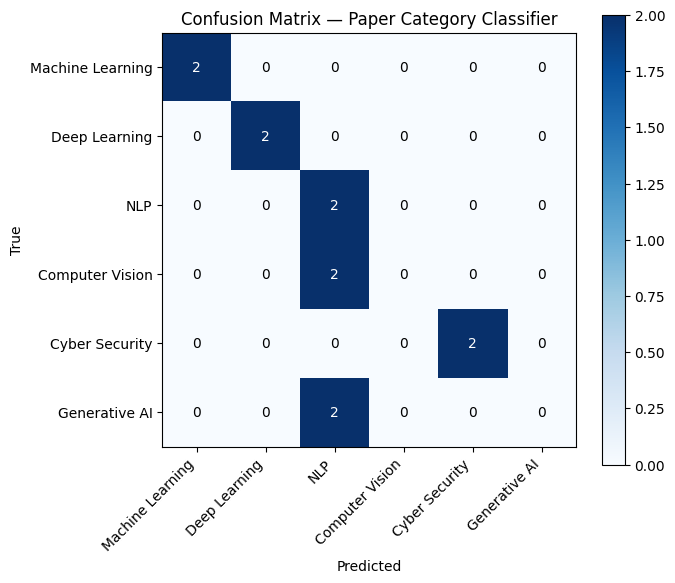

📄 IEEE_PAPER.pdf → predicted category: Generative AI


In [30]:
# ----- Evaluation on the (small) demo set -----
preds_output = trainer.predict(train_dataset)
preds = np.argmax(preds_output.predictions, axis=1)
true_labels = [label2id[l] for l in demo_labels]

acc = accuracy_score(true_labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, preds, average="weighted", zero_division=0
)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

cm = confusion_matrix(true_labels, preds, labels=list(range(len(CATEGORIES))))
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — Paper Category Classifier")
plt.xticks(range(len(CATEGORIES)), CATEGORIES, rotation=45, ha="right")
plt.yticks(range(len(CATEGORIES)), CATEGORIES)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()


def classify_paper(doc: PaperDocument) -> str:
    text = doc.abstract or doc.full_text[:512]
    inputs = tokenizer(text, truncation=True, padding=True, max_length=128, return_tensors="pt")
    with torch.no_grad():
        logits = classifier_model(**inputs).logits
    pred_id = int(torch.argmax(logits, dim=1))
    return id2label[pred_id]


for doc in papers:
    print(f"📄 {doc.filename} → predicted category: {classify_paper(doc)}")


## 1️⃣7️⃣ Recommendation System

Recommend similar papers/chunks using cosine similarity over embeddings, plus a
KMeans clustering view of the embedding space.


📚 Recommendations similar to: AgriAdvisor: A Conceptual Framework for


,source,similarity,preview
0,IEEE_PAPER.pdf,0.8303,. Machine learning and deep learning technique...
1,IEEE_PAPER.pdf,0.7804,. [19] “How To Build A Custom Agricultural Far...
2,IEEE_PAPER.pdf,0.7398,. The remainder of this paper lays out the arc...


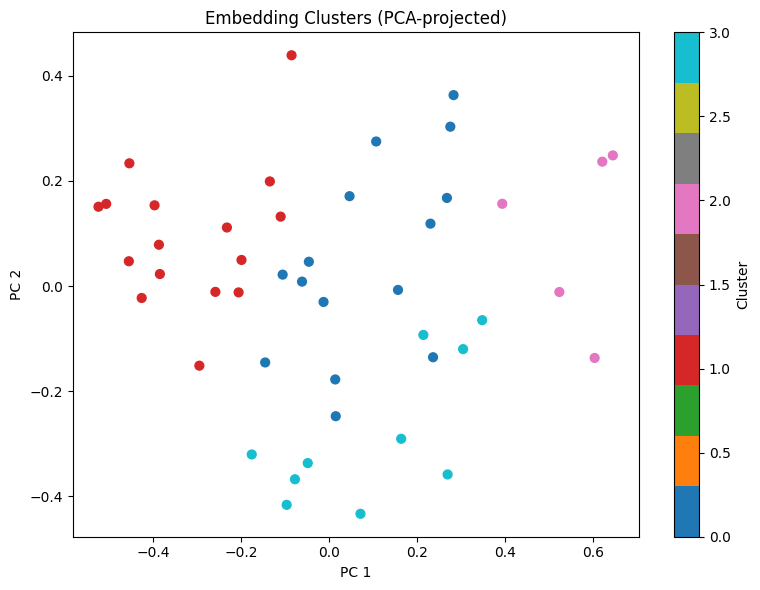

In [31]:
def recommend_similar(doc_index: int, top_n: int = 3) -> pd.DataFrame:
    """Recommend the most similar chunks (across all papers) to a given paper's abstract."""
    if not papers or len(chunk_embeddings) == 0:
        return pd.DataFrame()

    query_text = papers[doc_index].abstract or papers[doc_index].full_text[:1000]
    query_emb = embedding_model.encode([query_text], convert_to_numpy=True)

    sims = cosine_similarity(query_emb, chunk_embeddings)[0]
    top_idx = np.argsort(sims)[::-1][:top_n]

    rows = [
        {
            "source": all_chunks[i].source,
            "similarity": round(float(sims[i]), 4),
            "preview": textwrap.shorten(all_chunks[i].text, width=120),
        }
        for i in top_idx
    ]
    return pd.DataFrame(rows)


if papers:
    print(f"📚 Recommendations similar to: {papers[0].title}")
    display(recommend_similar(0))

# ----- Embedding clusters (KMeans) -----
if len(chunk_embeddings) >= 2:
    n_clusters = min(4, len(chunk_embeddings))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(chunk_embeddings)

    from sklearn.decomposition import PCA
    coords = PCA(n_components=2).fit_transform(chunk_embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap="tab10", s=40)
    plt.title("Embedding Clusters (PCA-projected)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()


## 1️⃣8️⃣ Knowledge Graph Generation

Build a graph connecting papers, authors, and extracted key concepts/models.


✅ Knowledge graph built: 10 nodes, 9 edges.


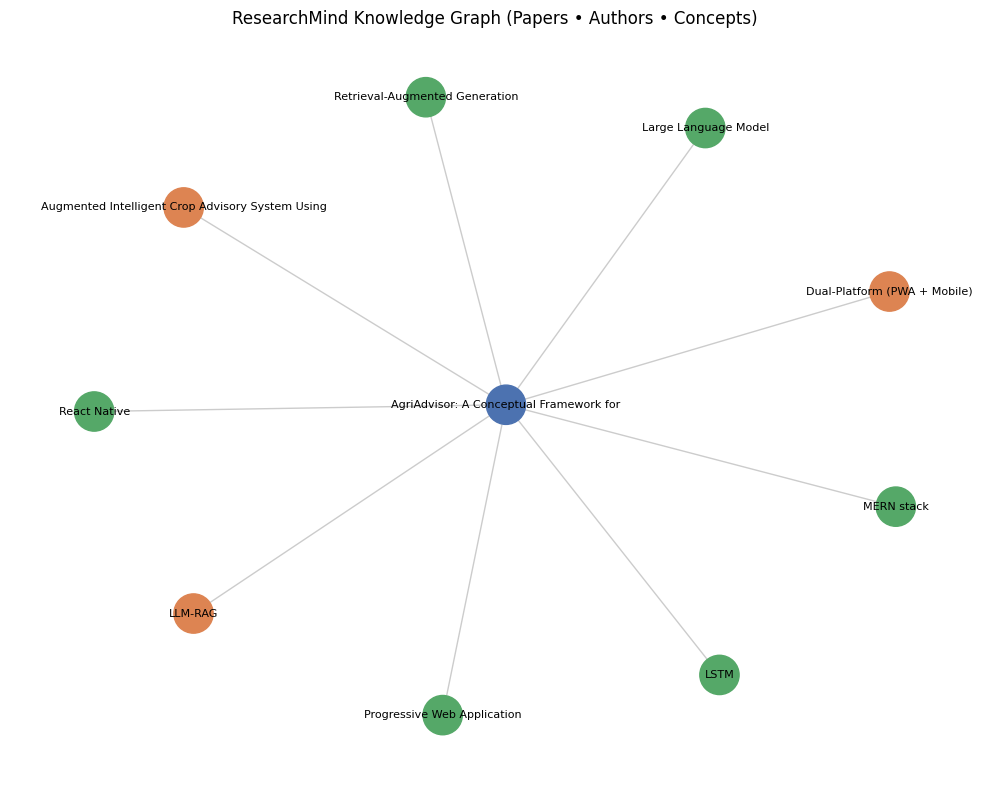

In [32]:
CONCEPT_EXTRACTION_PROMPT = (
    "Extract up to 6 key technical concepts or model names (e.g. Transformer, BERT, GPT, "
    "CNN, LSTM) mentioned in this text. Respond ONLY as a comma-separated list, no extra text.\n\n"
    "{text}"
)


def extract_concepts(doc: PaperDocument, model_key: str = "fast") -> List[str]:
    prompt = CONCEPT_EXTRACTION_PROMPT.format(text=doc.abstract or doc.full_text[:2000])
    try:
        llm = get_llm(model_key, temperature=0)
        response = llm.invoke([HumanMessage(content=prompt)])
        concepts = [c.strip() for c in response.content.split(",") if c.strip()]
        return concepts[:6]
    except Exception:
        return []


knowledge_graph = nx.Graph()

for doc in papers:
    paper_node = doc.title[:40] or doc.filename
    knowledge_graph.add_node(paper_node, type="paper")

    for author in re.split(r"[;,]", doc.authors):
        author = author.strip()
        if author and author.lower() != "unknown authors":
            knowledge_graph.add_node(author, type="author")
            knowledge_graph.add_edge(paper_node, author, relation="authored_by")

    for concept in extract_concepts(doc):
        knowledge_graph.add_node(concept, type="concept")
        knowledge_graph.add_edge(paper_node, concept, relation="discusses")

print(f"✅ Knowledge graph built: {knowledge_graph.number_of_nodes()} nodes, "
      f"{knowledge_graph.number_of_edges()} edges.")

# ----- Visualize -----
if knowledge_graph.number_of_nodes() > 0:
    color_map = {"paper": "#4C72B0", "author": "#DD8452", "concept": "#55A868"}
    node_colors = [
        color_map.get(knowledge_graph.nodes[n].get("type", "concept"), "#999999")
        for n in knowledge_graph.nodes
    ]

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(knowledge_graph, seed=42, k=0.6)
    nx.draw_networkx(
        knowledge_graph, pos, node_color=node_colors, node_size=800,
        font_size=8, edge_color="#cccccc", with_labels=True,
    )
    plt.title("ResearchMind Knowledge Graph (Papers • Authors • Concepts)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


## 1️⃣9️⃣ AI Agent System

We implement a lightweight multi-agent system. Each agent wraps a specific capability
built earlier, and an `Orchestrator` routes tasks to the right agent.


In [33]:
class BaseAgent:
    name: str = "BaseAgent"

    def run(self, **kwargs) -> str:
        raise NotImplementedError


class SearchAgent(BaseAgent):
    name = "SearchAgent"

    def run(self, query: str, k: int = 5) -> pd.DataFrame:
        return search_papers(query, k=k)


class SummarizationAgent(BaseAgent):
    name = "SummarizationAgent"

    def run(self, doc: PaperDocument, style: str = "short") -> str:
        return summarize_paper(doc, style=style)


class CitationAgent(BaseAgent):
    name = "CitationAgent"

    def run(self, doc: PaperDocument) -> Dict[str, str]:
        return generate_citations(doc)


class LiteratureReviewAgent(BaseAgent):
    name = "LiteratureReviewAgent"

    def run(self, topic: str) -> str:
        return generate_literature_review(topic)


class ResearchGapAgent(BaseAgent):
    name = "ResearchGapAgent"

    def run(self) -> str:
        return detect_research_gaps()


class Orchestrator:
    """Routes a natural-language task string to the appropriate specialized agent."""

    def __init__(self):
        self.agents = {
            "search": SearchAgent(),
            "summarize": SummarizationAgent(),
            "cite": CitationAgent(),
            "review": LiteratureReviewAgent(),
            "gaps": ResearchGapAgent(),
        }

    def route(self, task: str, **kwargs):
        task = task.lower()
        if "search" in task:
            return self.agents["search"].run(**kwargs)
        elif "summar" in task:
            return self.agents["summarize"].run(**kwargs)
        elif "cite" in task or "citation" in task:
            return self.agents["cite"].run(**kwargs)
        elif "review" in task:
            return self.agents["review"].run(**kwargs)
        elif "gap" in task:
            return self.agents["gaps"].run(**kwargs)
        else:
            return "⚠️ No matching agent found for this task."


orchestrator = Orchestrator()
print("✅ Agents initialized:", list(orchestrator.agents.keys()))

# Example interaction
if papers:
    print(orchestrator.route("summarize this paper", doc=papers[0], style="bullets"))


✅ Agents initialized: ['search', 'summarize', 'cite', 'review', 'gaps']
Here's a concise bullet-point list summarizing the paper:

* **Motivation:**
  - Agriculture employs a significant portion of India's workforce and contributes to the national GDP.
  - Most Indian farm households are small or marginal landholders with limited access to precision-agriculture infrastructure.
  - Machine learning and deep learning techniques have improved yield prediction accuracy, but the "delivery gap" – how predictions reach farmers – has been overlooked.
* **Method:**
  - A systematic review of nine peer-reviewed studies and real-world Large Language Model (LLM)-based farmer advisory systems.
  - Development of AgriAdvisor, a six-layer conceptual framework combining conventional ML-based prediction with LLM and Retrieval-Augmented Generation (RAG) advisory layers.
  - Dual-platform architecture using a MERN-based Progressive Web Application (PWA) and a React Native mobile application.
  - No IoT h

## 2️⃣0️⃣ Interactive UI (ipywidgets)

A simple in-notebook control panel: upload, ask questions, search, summarize, and compare.


In [34]:
output_area = widgets.Output()

question_box = widgets.Text(placeholder="Ask a question about the papers...", description="Question:")
ask_button = widgets.Button(description="Ask", button_style="primary")

search_box = widgets.Text(placeholder="Search term...", description="Search:")
search_button = widgets.Button(description="Search", button_style="info")

summary_style_dropdown = widgets.Dropdown(
    options=["short", "detailed", "beginner", "bullets"], description="Style:"
)
summary_button = widgets.Button(description="Summarize First Paper", button_style="success")

compare_button = widgets.Button(description="Show Comparison Table", button_style="warning")


def on_ask_clicked(_):
    with output_area:
        clear_output()
        if not question_box.value.strip():
            print("Please enter a question.")
            return
        try:
            print(ask_question(question_box.value))
        except Exception as e:
            print(f"⚠️ {e}")


def on_search_clicked(_):
    with output_area:
        clear_output()
        display(search_papers(search_box.value))


def on_summary_clicked(_):
    with output_area:
        clear_output()
        if not papers:
            print("No papers uploaded.")
            return
        try:
            print(summarize_paper(papers[0], style=summary_style_dropdown.value))
        except Exception as e:
            print(f"⚠️ {e}")


def on_compare_clicked(_):
    with output_area:
        clear_output()
        display(comparison_df)


ask_button.on_click(on_ask_clicked)
search_button.on_click(on_search_clicked)
summary_button.on_click(on_summary_clicked)
compare_button.on_click(on_compare_clicked)

ui = widgets.VBox([
    widgets.HBox([question_box, ask_button]),
    widgets.HBox([search_box, search_button]),
    widgets.HBox([summary_style_dropdown, summary_button]),
    compare_button,
    output_area,
])

display(ui)


## 2️⃣1️⃣ Additional Visualizations

A consolidated dashboard-style set of plots: topic distribution and similarity score
spread across all retrieved chunks for a sample query.


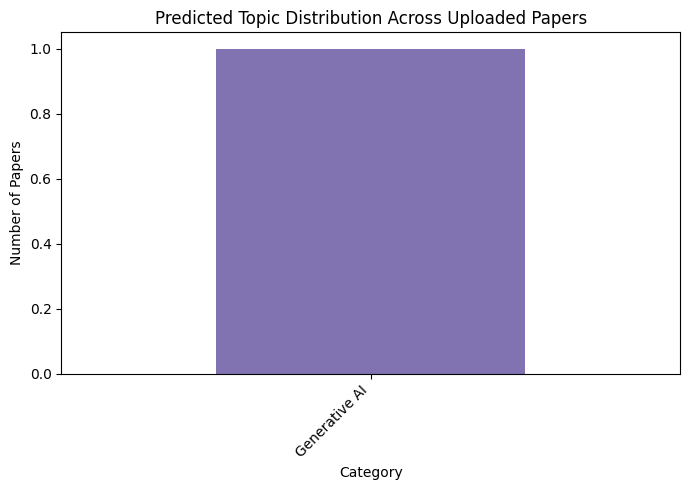

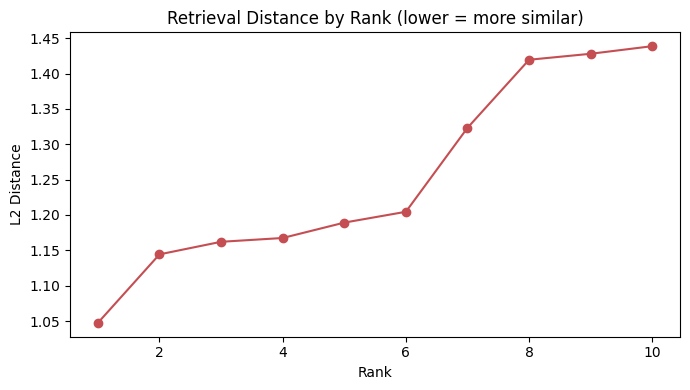

In [35]:
# ----- Topic distribution (based on classifier predictions) -----
if papers:
    predicted_categories = [classify_paper(doc) for doc in papers]
    cat_counts = pd.Series(predicted_categories).value_counts()

    plt.figure(figsize=(7, 5))
    cat_counts.plot(kind="bar", color="#8172B2")
    plt.title("Predicted Topic Distribution Across Uploaded Papers")
    plt.xlabel("Category")
    plt.ylabel("Number of Papers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ----- Similarity score spread for a sample query -----
sample_results = similarity_search("deep learning methodology", k=min(10, max(len(all_chunks), 1)))
if sample_results:
    dists = [d for _, d in sample_results]
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(dists) + 1), dists, marker="o", color="#C44E52")
    plt.title("Retrieval Distance by Rank (lower = more similar)")
    plt.xlabel("Rank")
    plt.ylabel("L2 Distance")
    plt.tight_layout()
    plt.show()


## 2️⃣2️⃣ Evaluation

We evaluate retrieval quality with Precision / Recall / F1 against a small manually
labelled relevance set, and provide a simple LLM-as-judge response-quality score.


In [36]:
def evaluate_retrieval(query: str, relevant_sources: List[str], k: int = 5) -> Dict[str, float]:
    """
    Precision/Recall/F1 for retrieval: treat a chunk as 'relevant' if it comes from
    one of the `relevant_sources` filenames provided by the user as ground truth.
    """
    results = similarity_search(query, k=k)
    if not results:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    retrieved_sources = [chunk.source for chunk, _ in results]
    true_positives = sum(1 for s in retrieved_sources if s in relevant_sources)

    precision = true_positives / len(retrieved_sources) if retrieved_sources else 0.0
    recall = true_positives / len(relevant_sources) if relevant_sources else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {"precision": round(precision, 3), "recall": round(recall, 3), "f1": round(f1, 3)}


# Example: treat all uploaded papers as "relevant" ground truth for a generic query
if papers:
    ground_truth = [doc.filename for doc in papers]
    metrics = evaluate_retrieval("main contribution of the paper", ground_truth, k=5)
    print("Retrieval metrics:", metrics)


def judge_response_quality(question: str, answer: str, model_key: str = "fast") -> str:
    """Simple LLM-as-judge: rate the answer's groundedness/relevance from 1-5 with justification."""
    prompt = (
        f"Question: {question}\nAnswer: {answer}\n\n"
        "Rate this answer's relevance and factual groundedness from 1 (poor) to 5 (excellent). "
        "Respond with: Score: <n>/5, Reason: <short reason>."
    )
    llm = get_llm(model_key, temperature=0)
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content


if papers:
    try:
        sample_answer = ask_question("What is the paper about?")
        print(judge_response_quality("What is the paper about?", sample_answer))
    except Exception as e:
        print(f"⚠️ Could not run response quality evaluation: {e}")


Retrieval metrics: {'precision': 1.0, 'recall': 5.0, 'f1': 1.667}
Score: 5/5, Reason: The answer accurately summarizes the main topic of the paper, including the specific issue of the "delivery gap" and the proposed solution of AgriAdvisor.


## 2️⃣3️⃣ Future Improvements

ResearchMind AI can be extended in several directions:

- **Multi-agent orchestration** with planning/critique loops (e.g. LangGraph) instead
  of simple keyword routing.
- **Voice assistant** integration (speech-to-text question input, text-to-speech answers).
- **Arxiv API integration** to auto-fetch related papers instead of requiring manual upload.
- **Citation prediction** — suggest which of a paper's own references are most likely
  to be cited together, using citation-graph embeddings.
- **Research roadmap generation** — turn detected research gaps into a structured,
  prioritized roadmap with estimated effort/impact.
- **Persistent vector store** (e.g. Chroma / Pinecone) so uploaded papers survive
  across sessions instead of being rebuilt each run.
- **Fine-tuned domain-specific embeddings** (e.g. SciBERT/SPECTER) for better
  scientific-text retrieval than general-purpose MiniLM.

---

### 🎉 You've reached the end of ResearchMind AI!

This notebook demonstrated a full pipeline spanning **PDF parsing, chunking, embeddings,
vector search, RAG, summarization, comparison, literature review generation, research
gap detection, citation generation, semantic search, transformer fine-tuning for
classification, recommendation, knowledge graphs, a lightweight agent system, and an
interactive UI** — all runnable end-to-end in Google Colab.
